Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

- Zapoznaj się z analizą zbioru [twarzy OLivetti](https://scikit-learn.org/stable/auto_examples/decomposition/plot_faces_decomposition.html)
- Zapoznaj się z ze zbiorem [klasyfikacji cyfr](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

1. [0-1 pkt] Załaduj zbiór cyfr, a następnie wyświetl pierwsze 6 (2 wiersze, 3 kolumny) elementów zbioru za pomocą funkcji `plot_gallery()` (zob. pierwszy link)
1. [0-0.5 pkt] Podziel zbiór na treningowy i walidacyjny (czy zbiór jest zbalansowany i wystarczy zwykły podział losowy?). Pamiętaj, że skalowanie cech jak i dostrojenie redukcji wymiarowości (metoda `fit`) przeprowadzamy na zbiorze treningowym!
1. [0-2.5 pkt] Dokonaj transformacji zbioru `digits` przy użyciu (w każdym przypadku wyrysuj kilka przykładowych elementów zbioru): 
   1. PCA
   2. [NMF](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html) (jaki będzie input?)
   3. [Factor Analysis](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FactorAnalysis.html)
   4. [Jądrowy PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html) (przy użyciu przynajmniej trzech nieliniowych jąder)
2. [0-1.5 pkt] Wytrenuj regresję logistyczną na zbiorze oryginalnym (model *baseline*) oraz przetransformowanym za pomocą technik z punktu 3.
1. [0-1.5 pkt] Sporządź analizę porównawczą wyników zarówno dla zbioru treningowego jak i walidacyjnego. Wyrysuj macierz pomyłek oraz metryki zbiorcze
3. [0-1 pkt] Wybierz $n=32, 16, 8, 4, 2$ dominujące cechy w każdej metodzie i wykonaj analizę w pkt. 5.
1. [0-1 pkt] Skomentuj uzyskane wyniki. Czy redukcja wymiarowości jest optymalnym rozwiązaniem w przypadku tego zbioru? Jeśli tak, to która? Jeśli żadna, to dlaczego?
2. [0-1 pkt] Zaproponuj usprawnienie metodologii wyżej (np. inną technikę selekcji cech)

# Zadanie dodatkowe [0-4] pkt

1. [0-3 pkt] Dokonaj redukcji wymiarowości za pomocą trzech wybranych metod nieliniowych ze zbioru: t-SNE, UMAP, TriMAP, PaCMAP, a następnie użyj tak przetransformowanego zbioru w naszym problemie klasyfikacji cyfr
2. [0-1 pkt] Czy użycie tych zaawansowanych technik ma sens w tym przypadku?

In [2]:
import matplotlib.pyplot as plt
import sklearn

### Zadanie 1 - funkcja plot gallery

In [3]:

def plot_gallery(title, images, n_col=3, n_row=2,image_shape = (8,8),cmap = plt.cm.gray):
    if images.shape[0] < n_col * n_row:
        images = images[: n_col * n_row]
    fig, axs = plt.subplots(
        nrows=n_row,
        ncols=n_col,
        figsize=(2.0 * n_col, 2.3 * n_row),        
        constrained_layout=True,
    )
    fig.get_layout_engine().set(w_pad=0.01, h_pad=0.02, hspace=0, wspace=0)
    fig.set_edgecolor("black")
    fig.suptitle(title, size=16)
    for ax, vec in zip(axs.flat, images):
        vmin = images.min()
        vmax = images.max()
        im = ax.imshow(
            vec.reshape(image_shape),
            cmap=cmap,
            interpolation="nearest",
            vmin= vmin,
            vmax=vmax,
        )
        ax.axis("off")

    fig.colorbar(im, ax=axs, orientation="horizontal", shrink=0.99, aspect=40, pad=0.01)
    plt.show()

załadowanie danych

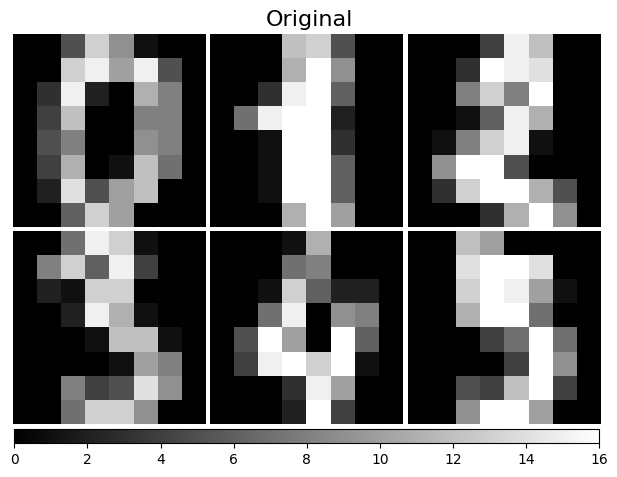

In [4]:
from sklearn.datasets import load_digits
digits = load_digits()
plot_gallery("Original", digits.data)


In [5]:
digits_data = digits.data
digits_target = digits.target

### Zadanie 2 - podział zbioru na treningowy i testowy

(array([178., 182., 177., 183., 181., 182., 181., 179., 174., 180.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

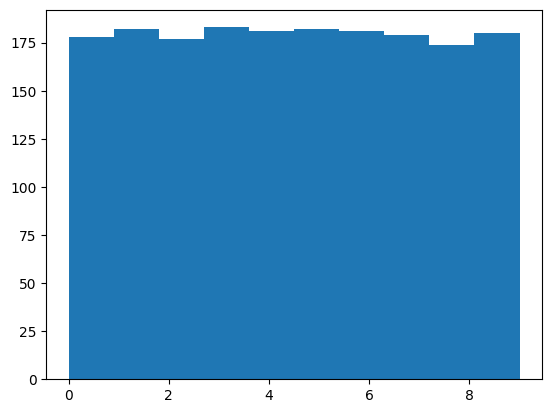

In [6]:
plt.hist(digits_target, bins=10)

zbiór jest zbalansowany więc podział losowy wystarczy, nie trzeba uzależniać proporcji od liczności klas

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=0)

### Zadnie 3 - transformacje digits

#### 1. PCA

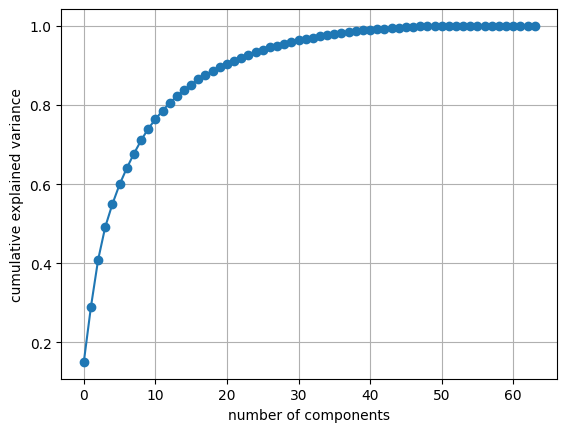

In [8]:
from sklearn.decomposition import PCA

pca_example= PCA().fit(X_train)
plt.plot(pca_example.explained_variance_ratio_.cumsum(), marker="o")
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.grid()
plt.show()

Original number of features: 64
Reduced number of features: 28


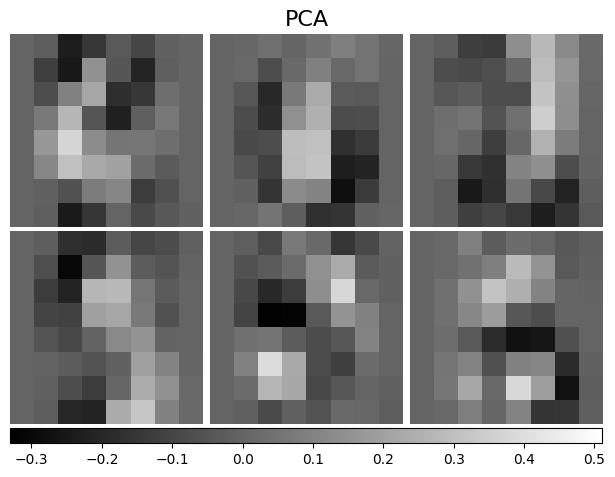

In [9]:
pca = PCA(n_components=0.95,random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features: {X_train_pca.shape[1]}")
plot_gallery("PCA", pca.components_, image_shape=(8,8))

#### 2. NMF

In [10]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nmf = NMF(n_components=30, random_state=0).fit(X_train_scaled)
X_train_nmf = nmf.transform(X_train_scaled)
X_test_nmf = nmf.transform(X_test_scaled)

/home/marek/work/studia/sem6/machine-learning-basis/.venv/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


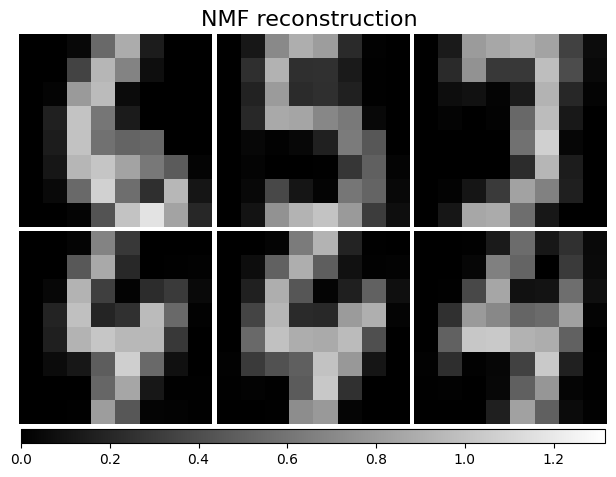

In [11]:
X_reconstructed = nmf.inverse_transform(X_train_nmf)
plot_gallery("NMF reconstruction", X_reconstructed)


#### 3. Factor Analysis

In [24]:
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

scaler_fa = StandardScaler()
X_train_standard_scaled = scaler_fa.fit_transform(X_train)

factor_analysis = FactorAnalysis(n_components=30, random_state=0).fit(X_train_standard_scaled)
X_train_fa = factor_analysis.transform(X_train_standard_scaled)
X_test_fa = factor_analysis.transform(scaler_fa.transform(X_test))

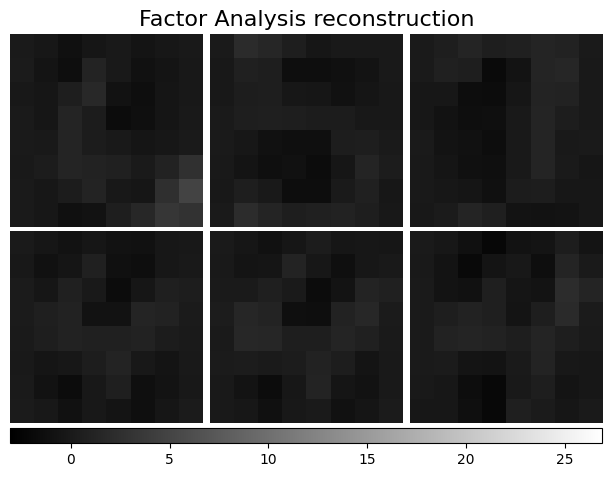

In [13]:
reconstructed_fa =X_train_fa @ factor_analysis.components_ + factor_analysis.mean_
plot_gallery("Factor Analysis reconstruction", reconstructed_fa)

#### 4. Jądrowy PCA

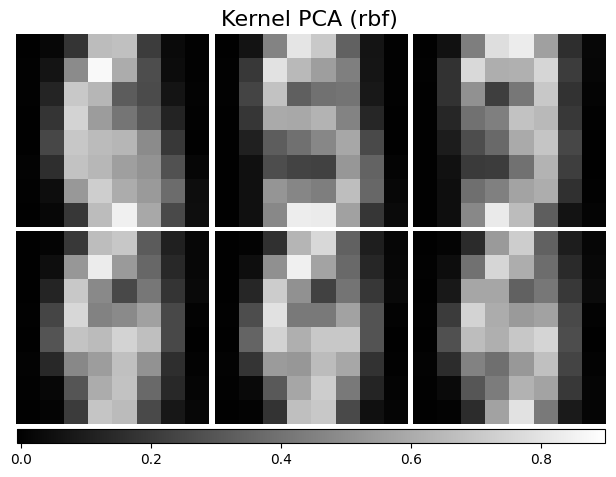

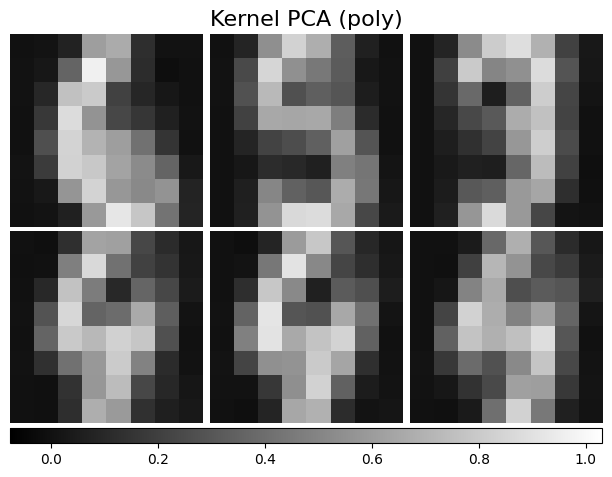

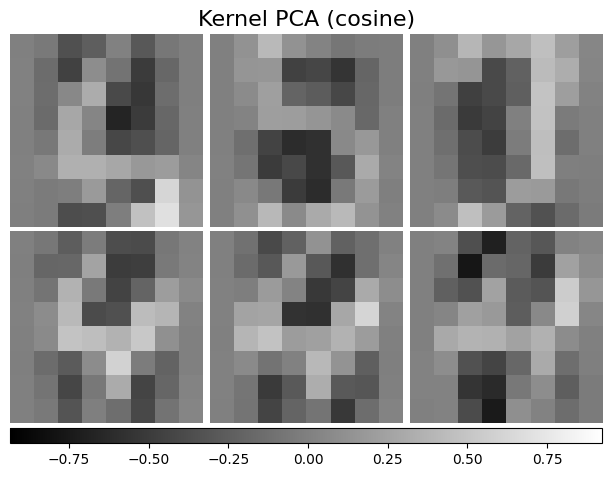

In [14]:
from sklearn.decomposition import KernelPCA

X_train_kpca = {}
X_test_kpca = {}

for kernel in ['rbf', 'poly', 'cosine']:
    kpca = KernelPCA(n_components=30, kernel=kernel, fit_inverse_transform=True, random_state=0)
    X_train_kpca[kernel]= kpca.fit_transform(X_train_scaled)
    X_test_kpca[kernel] = kpca.transform(X_test_scaled)
    X_reconstructed = kpca.inverse_transform(X_train_kpca[kernel])
    plot_gallery(f"Kernel PCA ({kernel})", X_reconstructed)


#### Zadanie 4 - trenowanie regresji logistycznej

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

#### Baseline

In [16]:
logreg_baseline = LogisticRegression(max_iter=1000, random_state=0).fit(X_train, y_train)

y_pred_baseline = logreg_baseline.predict(X_test)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average="macro")
print(f"Baseline accuracy: {accuracy_baseline:.4f}")
print(f"Baseline F1-score macro: {f1_baseline:.4f}")


Baseline accuracy: 0.9694
Baseline F1-score macro: 0.9702


#### PCA

In [17]:
logreg_pca = LogisticRegression(max_iter=1000, random_state=0).fit(X_train_pca, y_train)
y_pred_pca = logreg_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca, average="macro")
print(f"PCA accuracy: {accuracy_pca:.4f}")
print(f"PCA F1-score macro: {f1_pca:.4f}")

PCA accuracy: 0.9639
PCA F1-score macro: 0.9650


#### NMF

In [18]:
logreg_nmf = LogisticRegression(max_iter=1000, random_state=0).fit(X_train_nmf, y_train)
y_pred_nmf = logreg_nmf.predict(X_test_nmf)
accuracy_nmf = accuracy_score(y_test, y_pred_nmf)
f1_nmf = f1_score(y_test, y_pred_nmf, average="macro")
print(f"NMF accuracy: {accuracy_nmf:.4f}")
print(f"NMF F1-score macro: {f1_nmf:.4f}")

NMF accuracy: 0.7917
NMF F1-score macro: 0.7912


#### Factor analysis

In [25]:
logreg_fa = LogisticRegression(max_iter=1000, random_state=0).fit(X_train_fa, y_train)
y_pred_fa = logreg_fa.predict(X_test_fa)
accuracy_fa = accuracy_score(y_test, y_pred_fa)
f1_fa = f1_score(y_test, y_pred_fa, average="macro")
print(f"NMF accuracy: {accuracy_fa:.4f}")
print(f"NMF F1-score macro: {f1_fa:.4f}")

NMF accuracy: 0.9583
NMF F1-score macro: 0.9593


#### Kernel PCA - rbf

In [21]:
logreg_pca_rbf = LogisticRegression(max_iter=1000, random_state=0).fit(X_train_kpca['rbf'], y_train)
y_pred_pca_rbf = logreg_pca_rbf.predict(X_test_kpca['rbf'])
accuracy_pca_rbf = accuracy_score(y_test, y_pred_pca_rbf)
f1_pca_rbf = f1_score(y_test, y_pred_pca_rbf, average="macro")
print(f"Kernel PCA (RBF) accuracy: {accuracy_pca_rbf:.4f}")
print(f"Kernel PCA (RBF) F1-score macro: {f1_pca_rbf:.4f}")

Kernel PCA (RBF) accuracy: 0.9306
Kernel PCA (RBF) F1-score macro: 0.9319


#### Kernel PCA - polynomial

In [22]:
logreg_pca_poly = LogisticRegression(max_iter=1000, random_state=0).fit(X_train_kpca['poly'], y_train)
y_pred_pca_poly = logreg_pca_poly.predict(X_test_kpca['poly'])
accuracy_pca_poly = accuracy_score(y_test, y_pred_pca_poly)
f1_pca_poly = f1_score(y_test, y_pred_pca_poly, average="macro")
print(f"Kernel PCA (Poly) accuracy: {accuracy_pca_poly:.4f}")
print(f"Kernel PCA (Poly) F1-score macro: {f1_pca_poly:.4f}")


Kernel PCA (Poly) accuracy: 0.9389
Kernel PCA (Poly) F1-score macro: 0.9401


#### Kernel PCA - cosine

In [23]:
logreg_pca_cosine = LogisticRegression(max_iter=1000, random_state=0).fit(X_train_kpca['cosine'], y_train)
y_pred_pca_cosine = logreg_pca_cosine.predict(X_test_kpca['cosine'])
accuracy_pca_cosine = accuracy_score(y_test, y_pred_pca_cosine)
f1_pca_cosine = f1_score(y_test, y_pred_pca_cosine, average="macro")
print(f"Kernel PCA (Cosine) accuracy: {accuracy_pca_cosine:.4f}")
print(f"Kernel PCA (Cosine) F1-score macro: {f1_pca_cosine:.4f}")

Kernel PCA (Cosine) accuracy: 0.9444
Kernel PCA (Cosine) F1-score macro: 0.9468


### Zadanie 5,6 - analiza porównawcza

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import pandas as pd

models = {
    'Baseline': (logreg_baseline, X_train, X_test),
    'PCA':      (logreg_pca, X_train_pca, X_test_pca),
    'NMF':      (logreg_nmf, X_train_nmf, X_test_nmf),
    'FA':       (logreg_fa, X_train_fa, X_test_fa),
    'kPCA rbf': (logreg_pca_rbf, X_train_kpca['rbf'], X_test_kpca['rbf']),
    'kPCA poly':(logreg_pca_poly, X_train_kpca['poly'], X_test_kpca['poly']),
    'kPCA cosine':(logreg_pca_cosine, X_train_kpca['cosine'], X_test_kpca['cosine']),
}

rows = []
for name, (model, X_tr, X_te) in models.items():
    rows.append({
        'Model': name,
        'Train accuracy': accuracy_score(y_train, model.predict(X_tr)),
        'Test accuracy':  accuracy_score(y_test,  model.predict(X_te)),
        'Train F1 macro': f1_score(y_train, model.predict(X_tr), average='macro'),
        'Test F1 macro':  f1_score(y_test,  model.predict(X_te), average='macro'),
    })

df = pd.DataFrame(rows).set_index('Model').round(4)
print(df)


             Train accuracy  Test accuracy  Train F1 macro  Test F1 macro
Model                                                                    
Baseline             1.0000         0.9694          1.0000         0.9702
PCA                  1.0000         0.9639          1.0000         0.9650
NMF                  0.7982         0.7917          0.7948         0.7912
FA                   0.9875         0.9583          0.9872         0.9593
kPCA rbf             0.9367         0.9306          0.9359         0.9319
kPCA poly            0.9506         0.9389          0.9502         0.9401
kPCA cosine          0.9527         0.9444          0.9523         0.9468


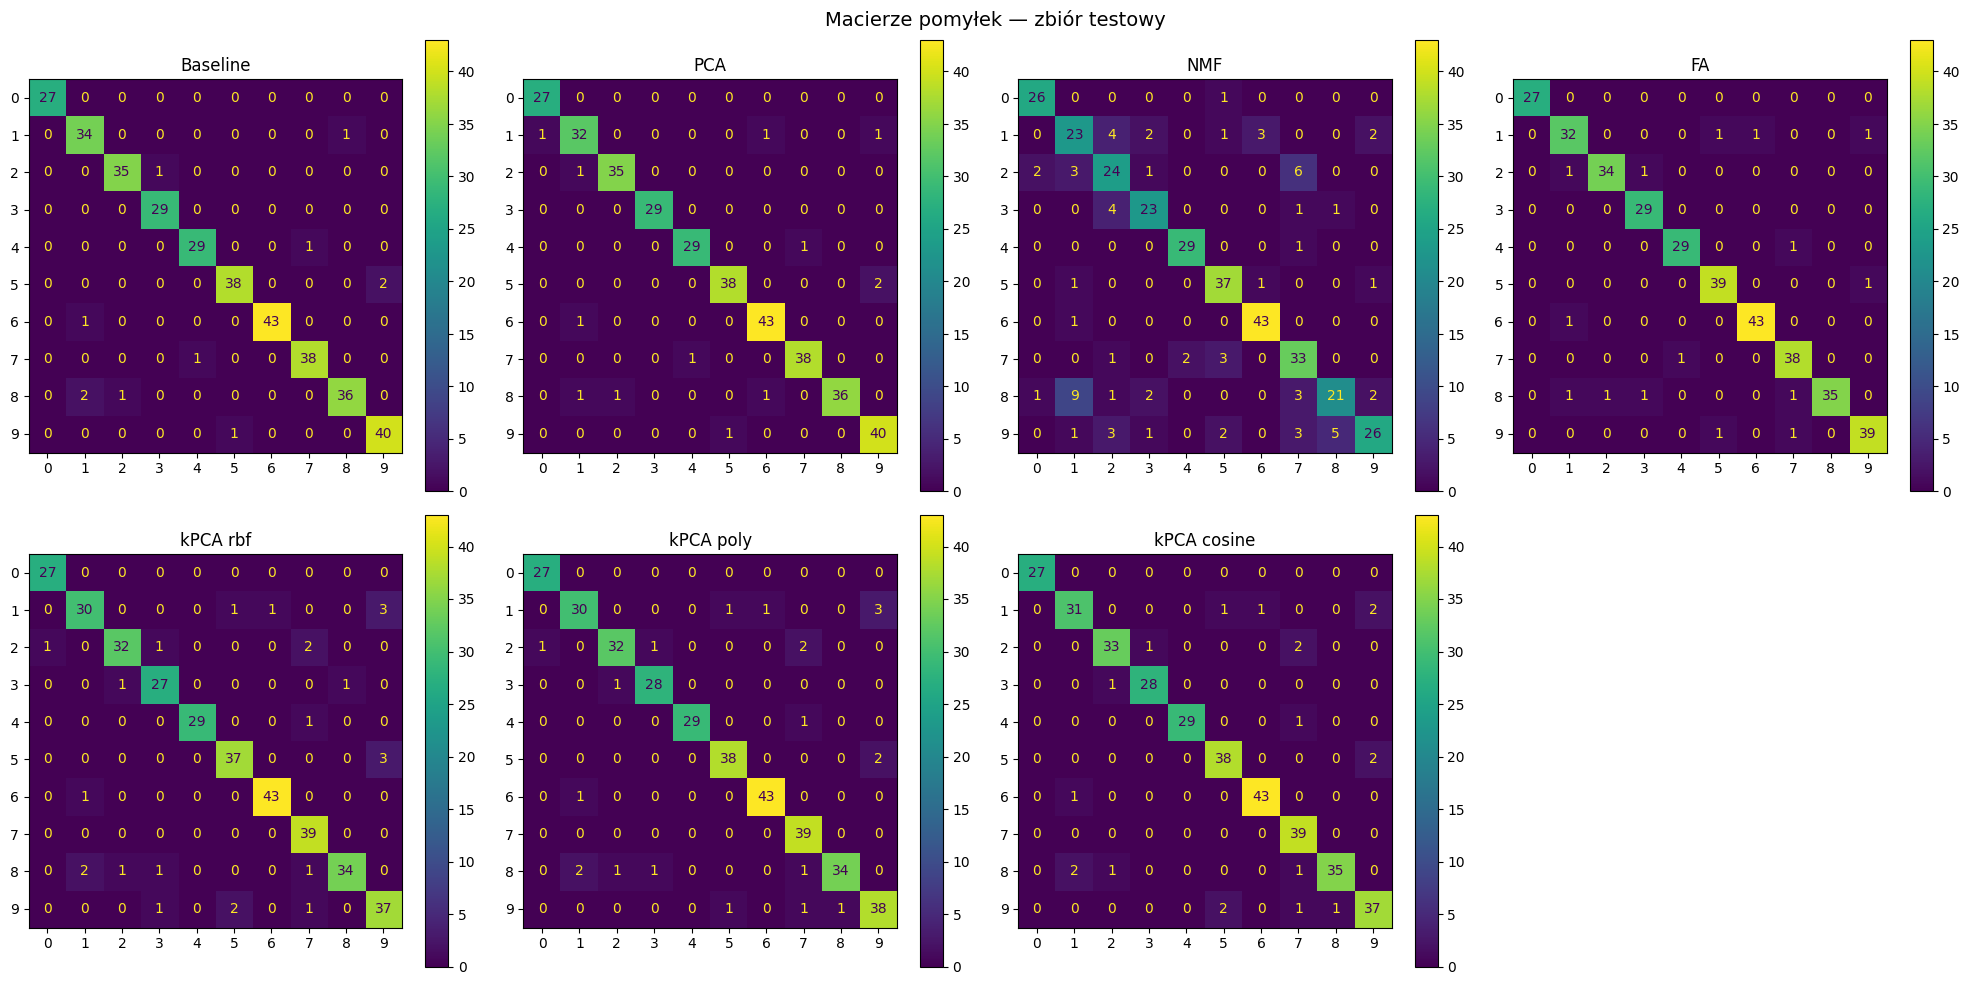

In [29]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flat

for ax, (name, (model, _, X_te)) in zip(axs, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_te), ax=ax)
    ax.set_title(name)
    ax.set_xlabel('')
    ax.set_ylabel('')

axs[-1].set_visible(False)
plt.suptitle("Macierze pomyłek — zbiór testowy", size=14)
plt.tight_layout()
plt.show()

In [32]:
n_components_list = [32, 16, 8, 4, 2]
rows = []

for n in n_components_list:
    # PCA
    pca_n = PCA(n_components=n, random_state=0).fit(X_train)
    Xtr_pca = pca_n.transform(X_train)
    Xte_pca = pca_n.transform(X_test)
    clf = LogisticRegression(max_iter=1000, random_state=0).fit(Xtr_pca, y_train)
    rows.append({'n': n, 'method': 'PCA',
                 'train_acc': accuracy_score(y_train, clf.predict(Xtr_pca)),
                 'test_acc':  accuracy_score(y_test,  clf.predict(Xte_pca)),
                 'test_f1':   f1_score(y_test, clf.predict(Xte_pca), average='macro')})

    # NMF
    nmf_n = NMF(n_components=n, max_iter=500, random_state=0).fit(X_train_scaled)
    Xtr_nmf = nmf_n.transform(X_train_scaled)
    Xte_nmf = nmf_n.transform(X_test_scaled)
    clf = LogisticRegression(max_iter=1000, random_state=0).fit(Xtr_nmf, y_train)
    rows.append({'n': n, 'method': 'NMF',
                 'train_acc': accuracy_score(y_train, clf.predict(Xtr_nmf)),
                 'test_acc':  accuracy_score(y_test,  clf.predict(Xte_nmf)),
                 'test_f1':   f1_score(y_test, clf.predict(Xte_nmf), average='macro')})

    # Factor Analysis
    fa_n = FactorAnalysis(n_components=n, random_state=0).fit(X_train_standard_scaled)
    Xtr_fa = fa_n.transform(X_train_standard_scaled)
    Xte_fa = fa_n.transform(scaler_fa.transform(X_test))
    clf = LogisticRegression(max_iter=1000, random_state=0).fit(Xtr_fa, y_train)
    rows.append({'n': n, 'method': 'FA',
                 'train_acc': accuracy_score(y_train, clf.predict(Xtr_fa)),
                 'test_acc':  accuracy_score(y_test,  clf.predict(Xte_fa)),
                 'test_f1':   f1_score(y_test, clf.predict(Xte_fa), average='macro')})

    # Kernel PCA
    for kernel in ['rbf', 'poly', 'cosine']:
        kpca_n = KernelPCA(n_components=n, kernel=kernel, random_state=0).fit(X_train_scaled)
        Xtr_k = kpca_n.transform(X_train_scaled)
        Xte_k = kpca_n.transform(X_test_scaled)
        clf = LogisticRegression(max_iter=1000, random_state=0).fit(Xtr_k, y_train)
        rows.append({'n': n, 'method': f'kPCA {kernel}',
                     'train_acc': accuracy_score(y_train, clf.predict(Xtr_k)),
                     'test_acc':  accuracy_score(y_test,  clf.predict(Xte_k)),
                     'test_f1':   f1_score(y_test, clf.predict(Xte_k), average='macro')})

df6 = pd.DataFrame(rows).round(4)
print(df6.pivot(index='n', columns='method', values='test_acc').sort_index(ascending=False))


/home/marek/work/studia/sem6/machine-learning-basis/.venv/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


method      FA     NMF     PCA  kPCA cosine  kPCA poly  kPCA rbf
n                                                               
32      0.9528  0.7556  0.9611       0.9472     0.9417    0.9306
16      0.9444  0.7639  0.9361       0.9306     0.9333    0.9250
8       0.8500  0.7472  0.9111       0.8694     0.8722    0.8694
4       0.7583  0.6194  0.7889       0.7583     0.7417    0.7139
2       0.4472  0.2917  0.5917       0.5528     0.5417    0.4861


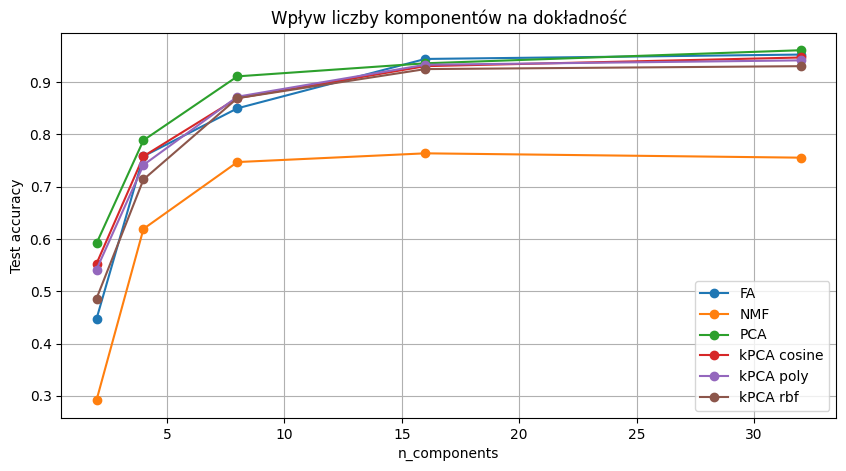

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
for method, grp in df6.groupby('method'):
    ax.plot(grp['n'], grp['test_acc'], marker='o', label=method)
ax.set_xlabel('n_components')
ax.set_ylabel('Test accuracy')
ax.set_title('Wpływ liczby komponentów na dokładność')
ax.legend()
ax.grid()
plt.show()


### Zadanie 7

Najlepszy wynik osiąga model baseline trenowany na surowych danych, bez redukcji wymiarów.
Modele trenowane na danych ze zredukowanymi wymiarami za pomocą standardowego PCA oraz FA tracą do niego poniżej punkta procentowego przy redukcji do 30 cech w porównaniu do 64 w surowych danych. Wyniki te sugerują, że cechy tego zbioru danych maja znaczną redundancję i można zredukować ich wymiarowość o ponad połowę za cenę nieznacznego pogorszenia się wyników modelu.
Wyraźnie gorzej niż pozostałe modele radzi sobie model wytenowany na danych, na których został użyty NMF.

Wraz ze zmniejszeniem się liczby cech, pogarszają się wyniki modeli. Przy zmianie z 32 na 16 spadki są nieznaczne, znaczną różnice widać jednak przy przejściu na 8 i mniej cech. Najbardziej odporny na zmniejszanie liczby parametrów wydaje się być PCA.

W przypadku tego zbioru redukcja wymiarowości nie wydaje się być optymalna, nie poprawia jakości modelu, a lekko ją pogarsza. Może to wynikać z faktu, że zbiór ma 64 cechy i podstawowy model nie wydaje się mieć problemów wynikających z klątwy wymiarowości. Ponadto regresja logistyczna z regularyzacją L2 dobrze radzi sobie z danymi w których występuje redundancja ze względu na możliwość "zerowania" parametrów.

### Zadanie 8

Zamiast redukcji wymiarowości możnaby zastosować selekcję cech.

Możnaby także dobrać hiperparametry metod redukcji wymiarów za pomocą gridsearchCV